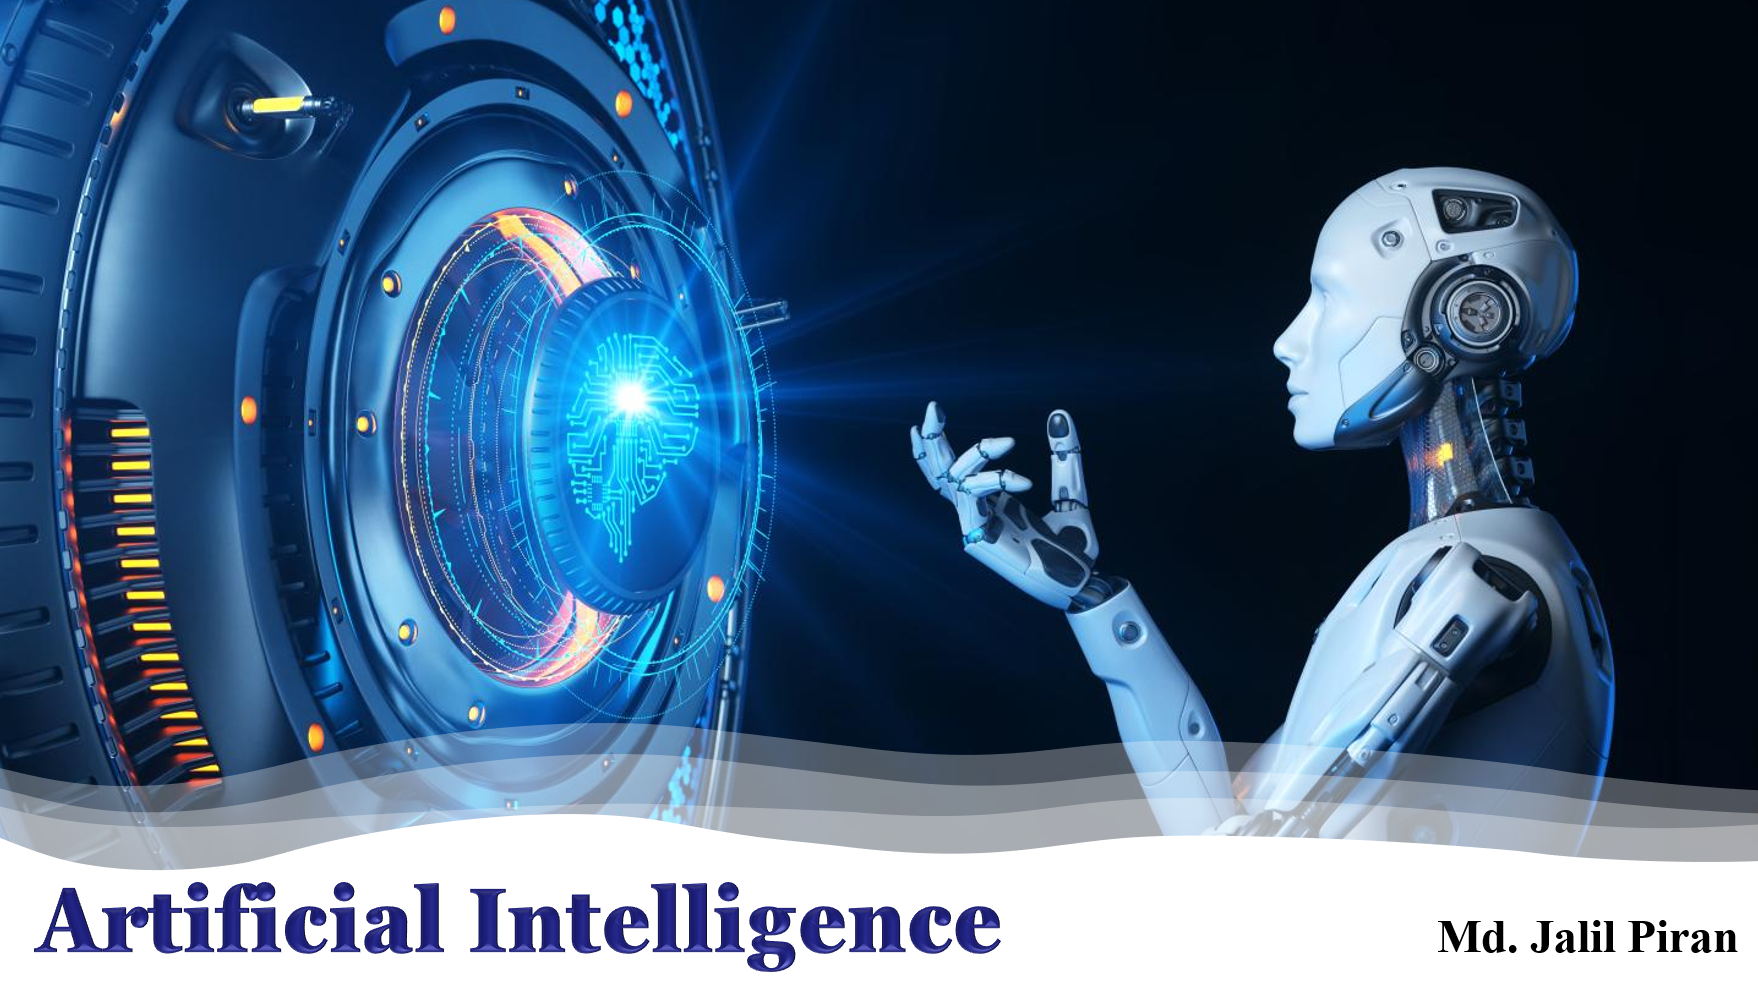

# Uninformed Search

* Run the code cells from top to bottom with Python 3.
* The visual examples require `networkx` and `matplotlib`.
* Install them with `%pip install networkx matplotlib` if needed.
* The numerical examples use only standard Python.
* Neighbour order determines traversal order when several choices are available.

## Breadth-First Search (BFS)

* **BFS with an adjacency list.**
  * The dictionary lists each node's outgoing neighbours.
  * BFS uses a first-in, first-out (FIFO) queue and marks nodes when they enter the queue, so a node reached through several edges is added only once.

In [1]:
graph = {
  '1' : ['2', '3','4'],
  '2' : ['5'],
  '3' : ['6'],
  '4' : ['6'],
  '5' : ['7'],
  '6' : ['7'],
  '7' : []
}
visited = []
queue = []

def bfs(visited, graph, node):
  visited.append(node)
  queue.append(node)
  while queue:          #visiting all nodes one by one
    m = queue.pop(0)
    print (m, end = " ")
    for neighbour in graph[m]:
      if neighbour not in visited:
        visited.append(neighbour)
        queue.append(neighbour)
print("Breadth-First Search")
bfs(visited, graph, '1')

Breadth-First Search
1 2 3 4 5 6 7 

* The output `1 2 3 4 5 6 7` is the nodes that are processed level by level, in the listed neighbour order.
* This is a traversal, not a single route; BFS finds minimum-edge paths when parent links are recorded.
* Here, `pop(0)` and list membership are linear-time operations, and the global queue must be reset before another call; the next example uses `deque` and a set.

* **Visualize BFS and recover a path.**
  * This example uses NetworkX to represent an undirected tree, `deque.popleft()` to remove the oldest queued node, and a parent dictionary to record each node's first discovery.
  * After the full traversal, it reconstructs the route to `K` by following parent links backward.

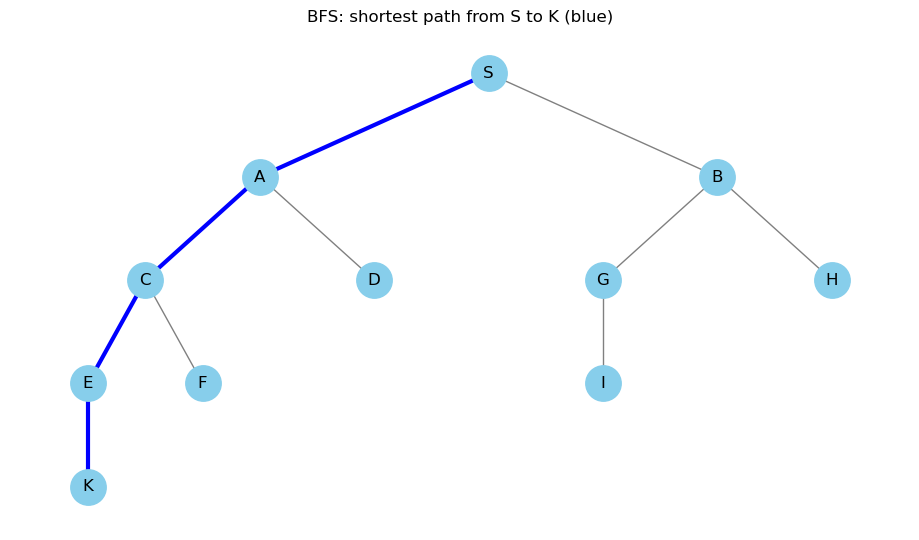

BFS traversal order: S -> A -> B -> C -> D -> G -> H -> E -> F -> I -> K
Shortest path from S to K: S -> A -> C -> E -> K


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def bfs_tree(graph, start):
    visited = {start}
    queue = deque([start])
    order = []
    parent = {start: None}
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                parent[neighbour] = node
                queue.append(neighbour)
    return order, parent

G = nx.Graph()
edges = [('S', 'A'), ('S', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'G'),
         ('B', 'H'), ('C', 'E'), ('C', 'F'), ('G', 'I'), ('E', 'K')]
G.add_edges_from(edges)
order, parent = bfs_tree(G, 'S')
path = []
node = 'K'
while node is not None:
    path.append(node)
    node = parent[node]
path.reverse()

# Fixed positions show the tree without requiring Graphviz.
pos = {'S': (0, 0), 'A': (-2, -1), 'B': (2, -1),
       'C': (-3, -2), 'D': (-1, -2), 'G': (1, -2), 'H': (3, -2),
       'E': (-3.5, -3), 'F': (-2.5, -3), 'I': (1, -3), 'K': (-3.5, -4)}
plt.figure(figsize=(9, 5))
nx.draw(G, pos, with_labels=True, node_size=650, node_color='skyblue', edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(path, path[1:])), edge_color='blue', width=3)
plt.title('BFS: shortest path from S to K (blue)')
plt.show()
print('BFS traversal order:', ' -> '.join(order))
print('Shortest path from S to K:', ' -> '.join(path))

**Order versus path.**
  * The traversal is `S -> A -> B -> C -> D -> G -> H -> E -> F -> I -> K`, whereas the blue path is `S -> A -> C -> E -> K` (four edges).
  * Consecutive nodes in a traversal need not share an edge.
  * BFS guarantees a minimum-edge path in an unweighted graph, but not a minimum-cost path when edge costs differ.

## Depth-First Search (DFS)

**Recursive DFS on a tree:**
  * DFS explores an unvisited neighbour recursively before returning to try the next neighbour.
  * The visited set prevents revisits, the call stack supports backtracking, and the parent dictionary records the discovery edges used to reconstruct a path.

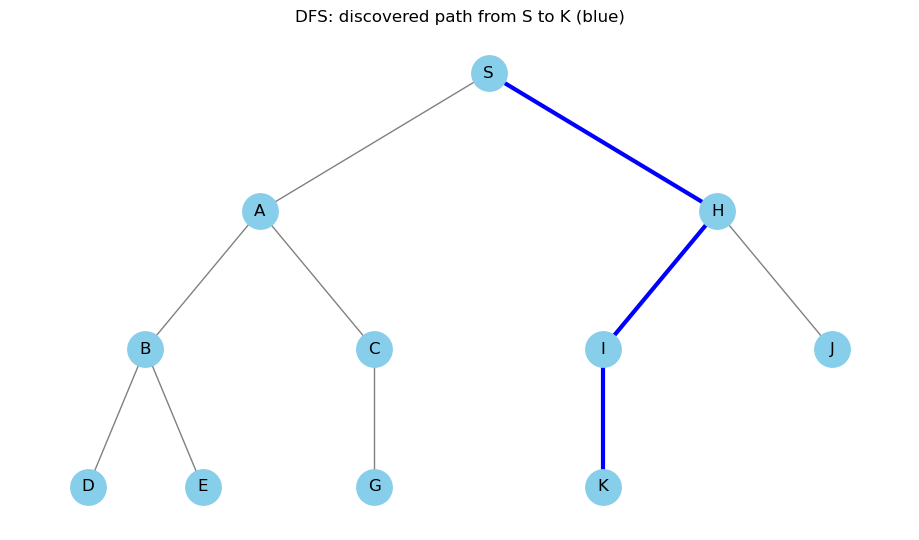

DFS traversal order: S -> A -> B -> D -> E -> C -> G -> H -> I -> K -> J
Discovered path from S to K: S -> H -> I -> K


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def dfs_tree(graph, node, visited, order, parent):
    visited.add(node)
    order.append(node)
    for neighbour in graph[node]:
        if neighbour not in visited:
            parent[neighbour] = node
            dfs_tree(graph, neighbour, visited, order, parent)

G = nx.Graph()
edges = [('S', 'A'), ('S', 'H'), ('A', 'B'), ('A', 'C'), ('B', 'D'),
         ('B', 'E'), ('C', 'G'), ('H', 'I'), ('H', 'J'), ('I', 'K')]
G.add_edges_from(edges)
order = []
parent = {'S': None}
dfs_tree(G, 'S', set(), order, parent)
path = []
node = 'K'
while node is not None:
    path.append(node)
    node = parent[node]
path.reverse()

pos = {'S': (0, 0), 'A': (-2, -1), 'H': (2, -1),
       'B': (-3, -2), 'C': (-1, -2), 'I': (1, -2), 'J': (3, -2),
       'D': (-3.5, -3), 'E': (-2.5, -3), 'G': (-1, -3), 'K': (1, -3)}
plt.figure(figsize=(9, 5))
nx.draw(G, pos, with_labels=True, node_size=650, node_color='skyblue', edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(path, path[1:])), edge_color='blue', width=3)
plt.title('DFS: discovered path from S to K (blue)')
plt.show()
print('DFS traversal order:', ' -> '.join(order))
print('Discovered path from S to K:', ' -> '.join(path))

**DFS backtracking.**
  * The traversal is `S -> A -> B -> D -> E -> C -> G -> H -> I -> K -> J`;
  * The blue route to `K` is `S -> H -> I -> K`. DFS continues through the whole tree in this example, even after visiting `K`.
  * A tree has only one simple path between two nodes; on a general graph, DFS does not guarantee a shortest path.

**DFS with an adjacency list.**
  * This compact version prints each node at its first visit and stores it in a set.
  * Neighbours are explored in list order, and recursion returns to earlier nodes when no unvisited neighbour remains.

In [4]:
#DFS
graph = {
  '1' : ['2', '3','4'],
  '2' : ['5'],
  '3' : ['6'],
  '4' : ['6'],
  '5' : ['7'],
  '6' : ['7'],
  '7' : []
}

visited = set()

def dfs(visited, graph, node):
    if node not in visited:
        print (node)
        visited.add(node)
        for neighbour in graph[node]:
            dfs(visited, graph, neighbour)

print("Following is the Depth-First Search")
dfs(visited, graph, '1')

Following is the Depth-First Search
1
2
5
7
3
6
4


**Follow the recursion.**
  * The output is `1, 2, 5, 7, 3, 6, 4`, with one node per line. Node `7` is not printed again when reached from `6`, because it is already visited.
  * With adjacency lists and expected constant-time set membership, this traversal takes $O(V+E)$ time over the reachable graph; very deep graphs can exceed Python's recursion limit.

## **Iterative Deepening Search (IDS)**

* IDS repeats depth-limited DFS with limits of 0, 1, 2, and so on, up to the inclusive `max_depth`.
* Each attempt starts afresh; the current path prevents cycles, and a successful call returns the actual route rather than an exploration log.

In [9]:
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['G'],
    'D': [],
    'E': ['F'],
    'G': [],
    'F': []
}

def depth_limited_search(graph, current, goal, remaining_depth, path):
    print('Checking for destination', current)
    if current == goal:
        return path.copy()
    if remaining_depth == 0:
        return None
    for neighbour in graph[current]:
        if neighbour not in path:  # Avoid cycles within the current path.
            result = depth_limited_search(
                graph, neighbour, goal, remaining_depth - 1, path + [neighbour]
            )
            if result is not None:
                return result
    return None

def iterative_deepening_search(graph, start, goal, max_depth):
    for limit in range(max_depth + 1):  # Include max_depth; root depth is zero.
        print(f'\nDepth limit: {limit}')
        result = depth_limited_search(graph, start, goal, limit, [start])
        if result is not None:
            return result
    return None

path = iterative_deepening_search(graph, 'A', 'G', max_depth=4)
if path is None:
    print('No path found within the depth limit.')
else:
    print('A path exists:', ' -> '.join(path))


Depth limit: 0
Checking for destination A

Depth limit: 1
Checking for destination A
Checking for destination B
Checking for destination C

Depth limit: 2
Checking for destination A
Checking for destination B
Checking for destination D
Checking for destination E
Checking for destination C
Checking for destination G
A path exists: A -> C -> G


* The checks are `A` at limit 0; `A, B, C` at limit 1; and `A, B, D, E, C, G` at limit 2.
* The returned path is `A -> C -> G`.
* Repeated visits across iterations are intentional: IDS finds a shallowest goal when the bound is sufficient, and this is cost-optimal only when all step costs are equal.
* Failure here means no path was found within the chosen bound.

## **Uniform-Cost Search (UCS)**

* UCS expands the frontier entry with the smallest accumulated cost $g(n)$, not the smallest depth.
* `heapq.heappush` maintains a min-heap and `heapq.heappop` removes its minimum; tuples compare their first element (`cost`) first, while `Node.__lt__` handles comparisons if those costs tie.
* This implementation requires nonnegative edge costs.

In [10]:
import heapq
class Node:
    def __init__(self, name, cost):
        self.name = name
        self.cost = cost
    def __lt__(self, other):
        return self.cost < other.cost
def uniform_cost_search(graph, start, goal):
    visited = set()
    priority_queue = [(0, Node(start, 0))]
    while priority_queue:
        cost, current_node = heapq.heappop(priority_queue)
        if current_node.name in visited:
            continue
        visited.add(current_node.name)
        if current_node.name == goal:
            return cost
        for neighbor, neighbor_cost in graph[current_node.name]:
            if neighbor not in visited:
                heapq.heappush(priority_queue, (cost + neighbor_cost, Node(neighbor, cost + neighbor_cost)))
    return float('inf')

graph = {
    'S': [('A', 1), ('B', 4)],
    'A': [('C', 3), ('D', 2)],
    'B': [('G', 5)],
    'C': [('E', 5)],
    'E': [('G', 5)],
    'D': [('G', 3)],
    'G': []
}
start_node = 'S'
goal_node = 'G'
result = uniform_cost_search(graph, start_node, goal_node)
if result != float('inf'):
    print(f"The cost of the cheapest path from {start_node} to {goal_node} is {result}.")
else:
    print(f"There is no path from {start_node} to {goal_node}.")

The cost of the cheapest path from S to G is 6.


* The printed result is `6`, achieved by `S -> A -> D -> G` with cost $1+2+3$. The function returns only the cost, not the route.
* A node is finalized when removed from the heap, and later duplicate entries are skipped; the goal is accepted at removal, not at first discovery, which is essential for UCS optimality.

# Informed Search

## Greedy Search

**Local Greedy: Choose the neighbour with the smallest heuristic.**
* This implementation follows one branch. It selects the smallest $h(n)$ among the current node's neighbours and ignores edge costs when making that choice.
* `visited` detects a cycle; `path` records the selected route. A dead end or a cycle causes failure without backtracking.
* This is a local greedy walk, not standard greedy best-first search, which keeps a frontier of all discovered candidates.
* The small correction `graph.get(current_node, [])` treats an omitted leaf as a dead end instead of raising `KeyError`.

Greedy Best-First
  Found path: S -> B -> F -> G
  Path cost: 6
  Node selection order: S -> B -> F -> G

Local greedy
  Found path: S -> B -> F -> G
  Path cost: 6
  Node selection order: S -> B -> F -> G

RESULT COMPARISON


,Algorithm,Found path,Path cost,Selection order,Nodes selected (including goal)
0,Greedy Best-First,S -> B -> F -> G,6,S -> B -> F -> G,4
1,Local greedy,S -> B -> F -> G,6,S -> B -> F -> G,4



STANDARD GREEDY BEST-FIRST: FRINGE AT EACH STEP


,Step,Fringe before,Selected,Added,Fringe after,Action
0,1,[S(h=13)],S,"[A(h=12), B(h=4)]","[B(h=4), A(h=12)]",Expand node
1,2,"[B(h=4), A(h=12)]",B,"[E(h=8), F(h=2)]","[F(h=2), E(h=8), A(h=12)]",Expand node
2,3,"[F(h=2), E(h=8), A(h=12)]",F,"[I(h=9), G(h=0)]","[G(h=0), E(h=8), I(h=9), A(h=12)]",Expand node
3,4,"[G(h=0), E(h=8), I(h=9), A(h=12)]",G,[],"[E(h=8), I(h=9), A(h=12)]",Goal selected: stop



LOCAL GREEDY: NEIGHBOR CHOICES AT EACH STEP
Local greedy does not retain a fringe of alternative branches.


,Step,Current,Neighbors,Next,Action
0,1,S,"[A(h=12), B(h=4)]",B,Move to lowest-h neighbor
1,2,B,"[E(h=8), F(h=2)]",F,Move to lowest-h neighbor
2,3,F,"[I(h=9), G(h=0)]",G,Move to lowest-h neighbor
3,4,G,Not examined,,Goal reached


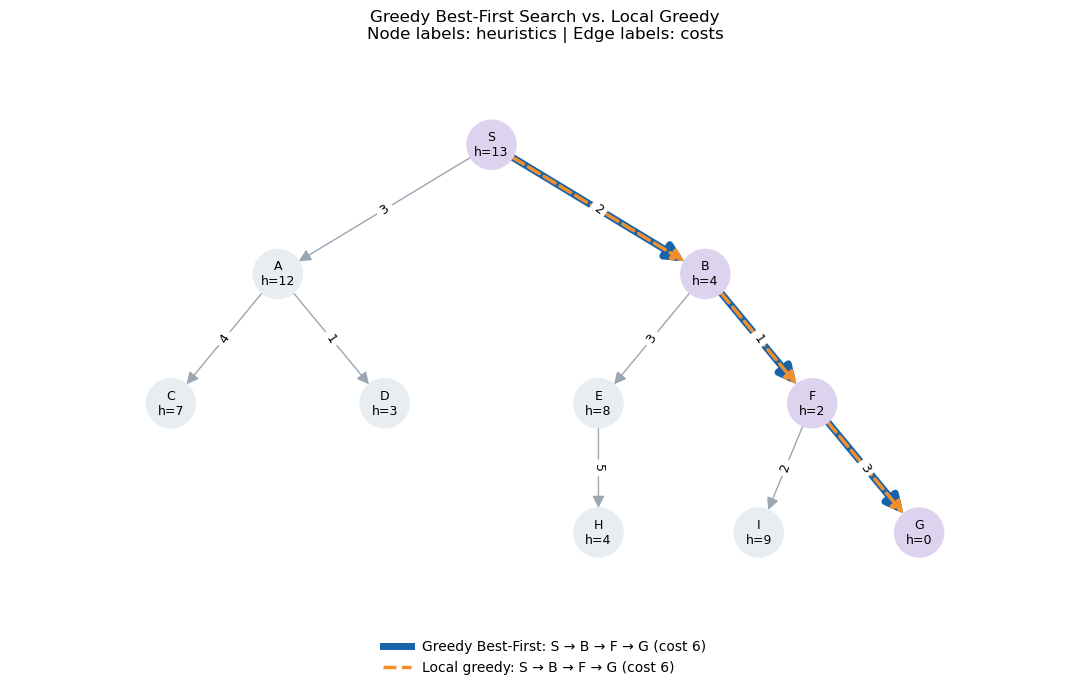

In [1]:
import heapq
from itertools import count
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

def format_nodes(nodes, h):
    return "[" + ", ".join(f"{n}(h={h[n]})" for n in nodes) + "]"

def path_cost(graph, path):
    return float("inf") if path is None else sum(
        next(c for n, c in graph[u] if n == v) for u, v in zip(path, path[1:]))

def local_greedy(graph, h, start, goal):
    path, steps, current = [], [], start
    while True:
        path.append(current)
        neighbors = graph.get(current, [])
        nxt = min(neighbors, key=lambda x: h[x[0]])[0] if neighbors else None
        action = ("Goal reached" if current == goal else "Dead end: stop" if not neighbors
                  else "Cycle detected: stop" if nxt in path else "Move to lowest-h neighbor")
        steps.append(dict(zip(
            ["Step", "Current", "Neighbors", "Next", "Action"],
            [len(steps) + 1, current,
             "Not examined" if current == goal else format_nodes([n for n, _ in neighbors], h),
             "" if current == goal or not neighbors else nxt, action])))
        if current == goal:
            return path, steps
        if not neighbors or nxt in path:
            return None, steps
        current = nxt

def greedy_best_first(graph, h, start, goal):
    counter, parent, steps = count(), {start: None}, []
    frontier = [(h[start], next(counter), start)]
    def fringe():
        return format_nodes([n for _, _, n in sorted(frontier)], h)
    while frontier:
        before, added = fringe(), []
        _, _, current = heapq.heappop(frontier)
        if current != goal:
            for n, _ in graph.get(current, []):
                if n not in parent:
                    parent[n] = current
                    heapq.heappush(frontier, (h[n], next(counter), n))
                    added.append(n)
        steps.append(dict(zip(
            ["Step", "Fringe before", "Selected", "Added", "Fringe after", "Action"],
            [len(steps) + 1, before, current, format_nodes(added, h), fringe(),
             "Goal selected: stop" if current == goal else "Expand node"])))
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1], steps
    return None, steps

def draw_search_graph(graph, heuristics, standard_path, local_path, positions):
    G = nx.DiGraph()
    G.add_nodes_from(heuristics)
    G.add_weighted_edges_from((u, v, c) for u in graph for v, c in graph[u])
    fig, ax = plt.subplots(figsize=(11, 7))
    s, l = set(standard_path or []), set(local_path or [])
    colors = ["#ddd3ef" if n in s & l else "#bce5f8" if n in s
              else "#ffe0b2" if n in l else "#e8edf2" for n in G]
    nx.draw_networkx(G, positions, ax=ax, node_color=colors, node_size=1250,
                     labels={n: f"{n}\nh={heuristics[n]}" for n in G},
                     font_size=9, edge_color="#9aa6b2", arrows=True, arrowsize=18)
    handles = []
    for name, path, color, width, style, size in [
        ("Greedy Best-First", standard_path, "#1764ab", 5, "-", 24),
        ("Local greedy", local_path, "#f28e2b", 2.5, "--", 17)
    ]:
        if path:
            nx.draw_networkx_edges(G, positions, ax=ax, edgelist=list(zip(path, path[1:])),
                                   edge_color=color, width=width, style=style,
                                   arrows=True, arrowsize=size, node_size=1250)
        label = (f"{name}: no solution" if path is None else
                 f"{name}: {' → '.join(path)} (cost {path_cost(graph, path):g})")
        handles.append(Line2D([0], [0], color=color, linewidth=width, linestyle=style, label=label))
    nx.draw_networkx_edge_labels(G, positions, ax=ax, font_size=9,
                                edge_labels=nx.get_edge_attributes(G, "weight"))
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=False)
    for text in ax.texts:
        text.set_zorder(5)
    ax.set_title("Greedy Best-First Search vs. Local Greedy\n"
                 "Node labels: heuristics | Edge labels: costs", pad=16)
    ax.axis("off")
    ax.margins(0.15)
    fig.tight_layout()
    plt.show()

greedy_graph = {
    'S': [('A', 3), ('B', 2)], 'A': [('C', 4), ('D', 1)],
    'B': [('E', 3), ('F', 1)], 'E': [('H', 5)], 'F': [('I', 2), ('G', 3)]
}
greedy_h = {'A': 12, 'B': 4, 'C': 7, 'D': 3, 'E': 8, 'F': 2, 'H': 4, 'I': 9, 'S': 13, 'G': 0}
greedy_positions = {
    'S': (0, 3), 'A': (-2, 2), 'B': (2, 2), 'C': (-3, 1), 'D': (-1, 1),
    'E': (1, 1), 'F': (3, 1), 'H': (1, 0), 'I': (2.5, 0), 'G': (4, 0)
}

standard_path, standard_steps = greedy_best_first(greedy_graph, greedy_h, 'S', 'G')
local_path, local_steps = local_greedy(greedy_graph, greedy_h, 'S', 'G')

results = []
for name, path, steps, column in [
    ("Greedy Best-First", standard_path, standard_steps, "Selected"),
    ("Local greedy", local_path, local_steps, "Current")
]:
    route = " -> ".join(path) if path is not None else "No solution"
    cost, order = path_cost(greedy_graph, path), " -> ".join(s[column] for s in steps)
    print(f"{name}\n  Found path: {route}\n  Path cost: {cost:g}\n  Node selection order: {order}\n")
    results.append([name, route, cost, order, len(steps)])

print("RESULT COMPARISON")
display(pd.DataFrame(results, columns=[
    "Algorithm", "Found path", "Path cost", "Selection order", "Nodes selected (including goal)"]))
print("\nSTANDARD GREEDY BEST-FIRST: FRINGE AT EACH STEP")
display(pd.DataFrame(standard_steps))
print("\nLOCAL GREEDY: NEIGHBOR CHOICES AT EACH STEP")
print("Local greedy does not retain a fringe of alternative branches.")
display(pd.DataFrame(local_steps))
draw_search_graph(greedy_graph, greedy_h, standard_path, local_path, greedy_positions)

| Current node | Candidate heuristics | Selected node |
|---|---|---|
| S | A: 12, B: 4 | B |
| B | E: 8, F: 2 | F |
| F | I: 9, G: 0 | G |

The returned path is `S -> B -> F -> G`, with cost $2+1+3=6$. The costs are used only to report the total. If the walk fails, a different branch may still contain a route to the goal. Equal heuristic values are resolved by neighbour list order.

## Standard Greedy Best-First Search with a priority queue. 
* It selects the node with the smallest heuristic \(h(n)\) from the entire frontier and retains alternative branches for later exploration.

Greedy Best-First Search: S -> B -> G | Cost: 6
Local greedy search: S -> A -> C -> G | Cost: 12

RESULT COMPARISON


,Algorithm,Found path,Path cost
0,Greedy Best-First Search,S -> B -> G,6
1,Local greedy search,S -> A -> C -> G,12



STANDARD GREEDY BEST-FIRST: FRINGE AT EACH STEP


,Step,Fringe before,Selected,Added,Fringe after,Action
0,1,[S(h=5)],S,"[A(h=2), B(h=3)]","[A(h=2), B(h=3)]",Expand node
1,2,"[A(h=2), B(h=3)]",A,[C(h=4)],"[B(h=3), C(h=4)]",Expand node
2,3,"[B(h=3), C(h=4)]",B,[G(h=0)],"[G(h=0), C(h=4)]",Expand node
3,4,"[G(h=0), C(h=4)]",G,[],[C(h=4)],Goal selected: stop



LOCAL GREEDY: NEIGHBOR CHOICES AT EACH STEP


,Step,Current,Neighbors,Next,Action
0,1,S,"[A(h=2), B(h=3)]",A,Move to lowest-h neighbor
1,2,A,[C(h=4)],C,Move to lowest-h neighbor
2,3,C,[G(h=0)],G,Move to lowest-h neighbor
3,4,G,Not examined,,Goal reached


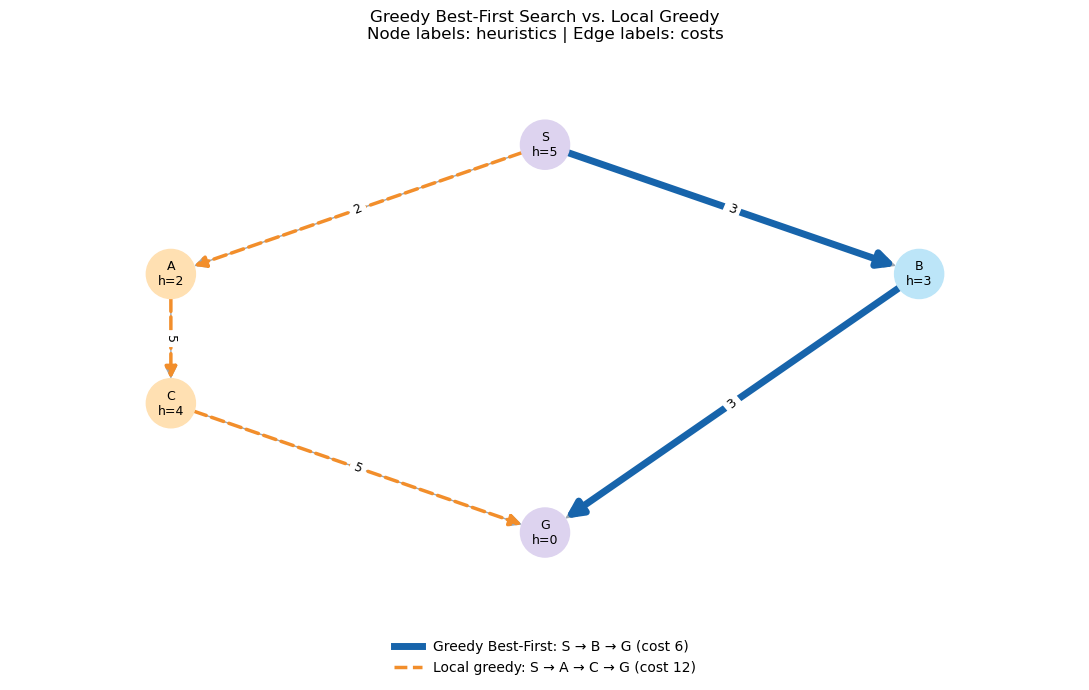

In [2]:
greedy_graph = {'S': [('A', 2), ('B', 3)], 'A': [('C', 5)], 'B': [('G', 3)], 'C': [('G', 5)]}
greedy_h = {'S': 5, 'A': 2, 'B': 3, 'C': 4, 'G': 0}
greedy_positions = {'S': (0, 3), 'A': (-2, 2), 'B': (2, 2), 'C': (-2, 1), 'G': (0, 0)}

standard_path, standard_steps = greedy_best_first(greedy_graph, greedy_h, 'S', 'G')
local_path, local_steps = local_greedy(greedy_graph, greedy_h, 'S', 'G')

results = []
for name, path in [('Greedy Best-First Search', standard_path), ('Local greedy search', local_path)]:
    route, cost = ' -> '.join(path) if path is not None else 'No solution found', path_cost(greedy_graph, path)
    print(f'{name}: {route}' + (f' | Cost: {cost:g}' if path is not None else ''))
    results.append([name, route, cost])

for title, table in [
    ('RESULT COMPARISON', pd.DataFrame(results, columns=['Algorithm', 'Found path', 'Path cost'])),
    ('STANDARD GREEDY BEST-FIRST: FRINGE AT EACH STEP', pd.DataFrame(standard_steps)),
    ('LOCAL GREEDY: NEIGHBOR CHOICES AT EACH STEP', pd.DataFrame(local_steps))
]:
    print(f'\n{title}')
    display(table)

draw_search_graph(greedy_graph, greedy_h, standard_path, local_path, greedy_positions)

## A* with an Adjacency List

**Combine cost so far and estimated cost to go.**

$$f(n)=g(n)+h(n).$$

* `g_score` stores the cheapest discovered cost from the start. The heap prioritizes $f(n)$ across the entire frontier.
* Each entry stores `(f, tie_breaker, g, node, path)`. A counter resolves ties in insertion order. Old entries are skipped if a cheaper route has already been recorded.
* The supplied code initialized the start priority to zero and then subtracted its heuristic. Consequently, its priorities were shifted by $-h(S)$ rather than representing $g+h$. Here, the start priority is `H_table[start]`, and `g` is tracked explicitly.
* A better route creates a new heap entry, even for a previously expanded node. This permits reopening. Missing adjacency entries are treated as leaves.


| Removed node | $g$ | $h$ | $f$ | Action |
|---|---:|---:|---:|---|
| S | 0 | 5 | 5 | Discover A and G |
| A | 1 | 3 | 4 | Discover B and C |
| C | 2 | 2 | 4 | Discover D; improve G from 10 to 6 |
| G | 6 | 0 | 6 | Return the goal path |

The route is `S -> A -> C -> G`, with cost $1+1+4=6$, compared with 10 for the direct edge. The goal is accepted when removed from the heap, not when first discovered.

**Heuristic conditions.** On a finite graph with nonnegative edge costs, this reopening implementation returns an optimal path when the heuristic is admissible and $h(G)=0$. Consistency additionally requires $h(u)\leq c(u,v)+h(v)$. The supplied table is inconsistent on `S -> A`, because $5>1+3$, but it is admissible for this directed graph. Nodes B and D cannot reach G, so their true remaining costs are infinite. Reopening matters when an admissible heuristic is inconsistent.

Greedy Best-First: S → G | Cost: 10
A*: S → A → C → G | Cost: 6


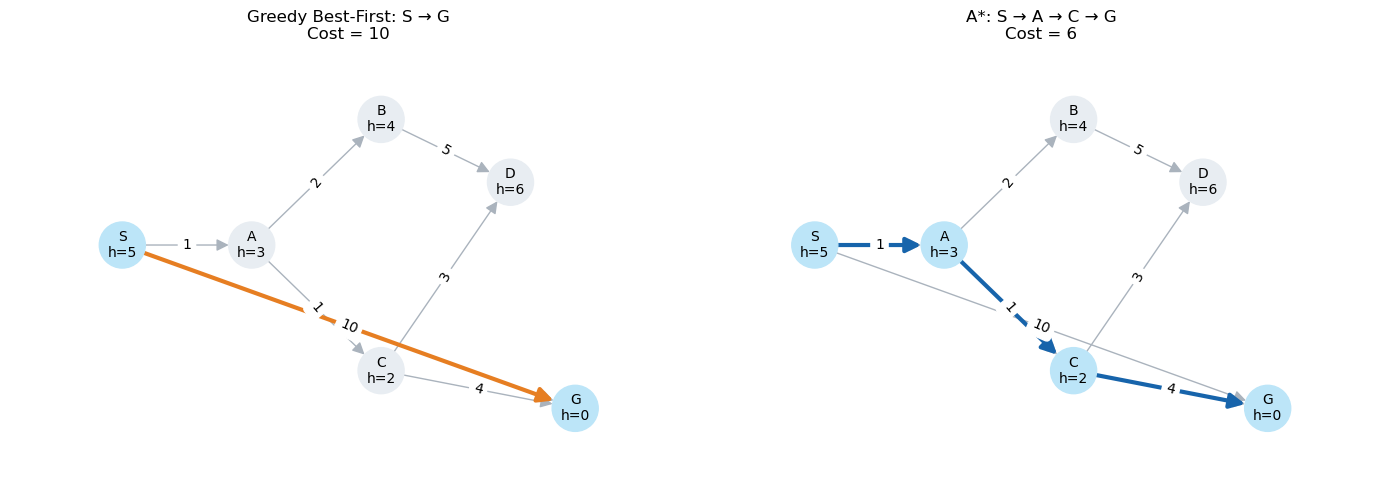

In [3]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Directed graph: (source, destination, edge cost)
G = nx.DiGraph()
G.add_weighted_edges_from([
    ('S', 'A', 1), ('S', 'G', 10), ('A', 'B', 2),
    ('A', 'C', 1), ('B', 'D', 5), ('C', 'D', 3), ('C', 'G', 4)
])
h = {'S': 5, 'A': 3, 'B': 4, 'C': 2, 'D': 6, 'G': 0}
pos = {
    'S': (0, 1), 'A': (1, 1), 'B': (2, 2),
    'C': (2, 0), 'D': (3, 1.5), 'G': (3.5, -0.3)
}


def search(astar=False, start='S', goal='G'):
    queue = [(h[start], 0, start, [start])]
    best = {start: 0}

    while queue:
        _, cost, node, path = heapq.heappop(queue)
        if cost != best[node]:
            continue
        if node == goal:
            return path, cost

        for neighbor in G[node]:
            new_cost = cost + G[node][neighbor]['weight']
            if neighbor not in best or (
                astar and new_cost < best[neighbor]
            ):
                best[neighbor] = new_cost
                priority = h[neighbor] + (new_cost if astar else 0)
                heapq.heappush(
                    queue, (priority, new_cost, neighbor, path + [neighbor])
                )

    return None, float('inf')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, astar, color in [
    (axes[0], 'Greedy Best-First', False, '#e67e22'),
    (axes[1], 'A*', True, '#1764ab')
]:
    path, cost = search(astar)
    route = ' → '.join(path) if path else 'No path'
    print(f'{name}: {route} | Cost: {cost:g}')

    nx.draw_networkx(
        G, pos, ax=ax,
        labels={n: f'{n}\nh={h[n]}' for n in G},
        node_color=['#bce5f8' if n in (path or []) else '#e8edf2' for n in G],
        node_size=1100, font_size=10, edge_color='#aab3bd', arrowsize=18
    )
    if path:
        nx.draw_networkx_edges(
            G, pos, ax=ax, edgelist=list(zip(path, path[1:])),
            edge_color=color, width=3, arrowsize=22, node_size=1100
        )
    nx.draw_networkx_edge_labels(
        G, pos, ax=ax, edge_labels=nx.get_edge_attributes(G, 'weight')
    )
    ax.set_title(f'{name}: {route}\nCost = {cost:g}')
    ax.margins(0.18)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Object-Oriented A*: Romania Map

**Represent cities as objects.**
* Each `Node` stores its name, heuristic, neighbours, best discovered $g$ and $f$, and parent. The heuristic estimates distance to Bucharest in kilometres.
* `parent` links recover the route by tracing backward from the goal and then reversing the list.
* The original code changed `neighbor.f` while the object could still be inside the heap. Python does not automatically restore heap order after that mutation. This version pushes a fresh tuple with a fixed numeric priority after every improvement.
* All reachable nodes are reset before each call, so the same city objects can be reused. A counter handles tied priorities; `Node.__lt__` is therefore unnecessary. Improved nodes may be reopened.

In [4]:
import heapq
from itertools import count

class Node:
    def __init__(self, name, heuristic):
        self.name, self.heuristic = name, heuristic
        self.adjacency_list, self.parent = [], None
        self.g = self.f = float('inf')

def a_star(start_node, goal_node):
    pending, seen = [start_node], set()
    while pending:
        node = pending.pop()
        if node in seen: continue
        seen.add(node)
        node.g = node.f = float('inf')
        node.parent = None
        pending.extend(n for n, _ in node.adjacency_list)

    start_node.g, start_node.f = 0, start_node.heuristic
    ties = count()
    queue = [(start_node.f, next(ties), 0, start_node)]
    while queue:
        _, _, saved_g, node = heapq.heappop(queue)
        if saved_g != node.g: continue
        if node is goal_node:
            path = []
            while node is not None:
                path.append(node.name)
                node = node.parent
            return path[::-1]
        for neighbor, cost in node.adjacency_list:
            if cost < 0: raise ValueError('A* requires nonnegative edge costs here.')
            g = node.g + cost
            if g < neighbor.g:
                neighbor.parent, neighbor.g, neighbor.f = node, g, g + neighbor.heuristic
                heapq.heappush(queue, (neighbor.f, next(ties), g, neighbor))
    return None

In [5]:
arad = Node('Arad', 366)
bucharest = Node('Bucharest', 0)
craiova = Node('Craiova', 160)
dobreta = Node('Dobreta', 242)
eforie = Node('Eforie', 161)
fagaras = Node('Fagaras', 178)
giurgiu = Node('Giurgiu', 77)
hirsova = Node('Hirsova', 151)
iasi = Node('Iasi', 226)
lugoj = Node('Lugoj', 244)
mehadia = Node('Mehadia', 241)
neamt = Node('Neamt', 234)
oradea = Node('Oradea', 380)
pitesti = Node('Pitesti', 98)
rimnicu_vilcea = Node('Rimnicu Vilcea', 193)
sibiu = Node('Sibiu', 253)
timisoara = Node('Timisoara', 329)
urziceni = Node('Urziceni', 80)
vaslui = Node('Vaslui', 199)
zerind = Node('Zerind', 374)

In [6]:
arad.adjacency_list = [(zerind, 75), (sibiu, 140), (timisoara, 118)]
zerind.adjacency_list = [(arad, 75), (oradea, 71)]
oradea.adjacency_list = [(zerind, 71), (sibiu, 151)]
sibiu.adjacency_list = [(arad, 140), (oradea, 151), (fagaras, 99), (rimnicu_vilcea, 80)]
fagaras.adjacency_list = [(sibiu, 99), (bucharest, 211)]
rimnicu_vilcea.adjacency_list = [(sibiu, 80), (pitesti, 97), (craiova, 146)]
pitesti.adjacency_list = [(rimnicu_vilcea, 97), (bucharest, 101)]
timisoara.adjacency_list = [(arad, 118), (lugoj, 111)]
lugoj.adjacency_list = [(timisoara, 111), (mehadia, 70)]
mehadia.adjacency_list = [(lugoj, 70), (dobreta, 75)]
dobreta.adjacency_list = [(mehadia, 75), (craiova, 120)]
craiova.adjacency_list = [(dobreta, 120), (rimnicu_vilcea, 146), (pitesti, 138)]
bucharest.adjacency_list = [(fagaras, 211), (pitesti, 101), (giurgiu, 90), (urziceni, 85)]
giurgiu.adjacency_list = [(bucharest, 90)]
urziceni.adjacency_list = [(bucharest, 85), (hirsova, 98), (vaslui, 142)]
hirsova.adjacency_list = [(urziceni, 98), (eforie, 86)]
eforie.adjacency_list = [(hirsova, 86)]
vaslui.adjacency_list = [(urziceni, 142), (iasi, 92)]
iasi.adjacency_list = [(vaslui, 92), (neamt, 87)]
neamt.adjacency_list = [(iasi, 87)]

In [5]:
romania_path = a_star(arad, bucharest)
if romania_path is not None:
    print('Path from Arad to Bucharest:', ' -> '.join(romania_path))
    print('Total distance:', bucharest.g, 'km')
else:
    print('No path found.')

Path from Arad to Bucharest: Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest
Total distance: 418 km



The returned route is `Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest`, with total distance $140+80+97+101=418$ km. The route through Fagaras costs $140+99+211=450$ km.

| Node removed | $g$ | $h$ | $f$ |
|---|---:|---:|---:|
| Arad | 0 | 366 | 366 |
| Sibiu | 140 | 253 | 393 |
| Rimnicu Vilcea | 220 | 193 | 413 |
| Fagaras | 239 | 178 | 417 |
| Pitesti | 317 | 98 | 415 |
| Bucharest | 418 | 0 | 418 |

Fagaras first discovers Bucharest at cost 450; Pitesti improves that cost to 418. Expanding Fagaras does not put it on the final route. The supplied heuristic is inconsistent on `Sibiu -> Fagaras` because $253>99+178$; the implementation supports reopening. The values are retained rather than silently replaced with another Romania heuristic table.

**Visualize the full road network.** The layout is schematic, not geographic. For readability, reciprocal roads are drawn as single lines; the one-way Craiova-to-Pitesti connection is marked with an arrow. Node labels include the supplied heuristics.

Arad → Sibiu → Rimnicu Vilcea → Pitesti → Bucharest | Cost: 418


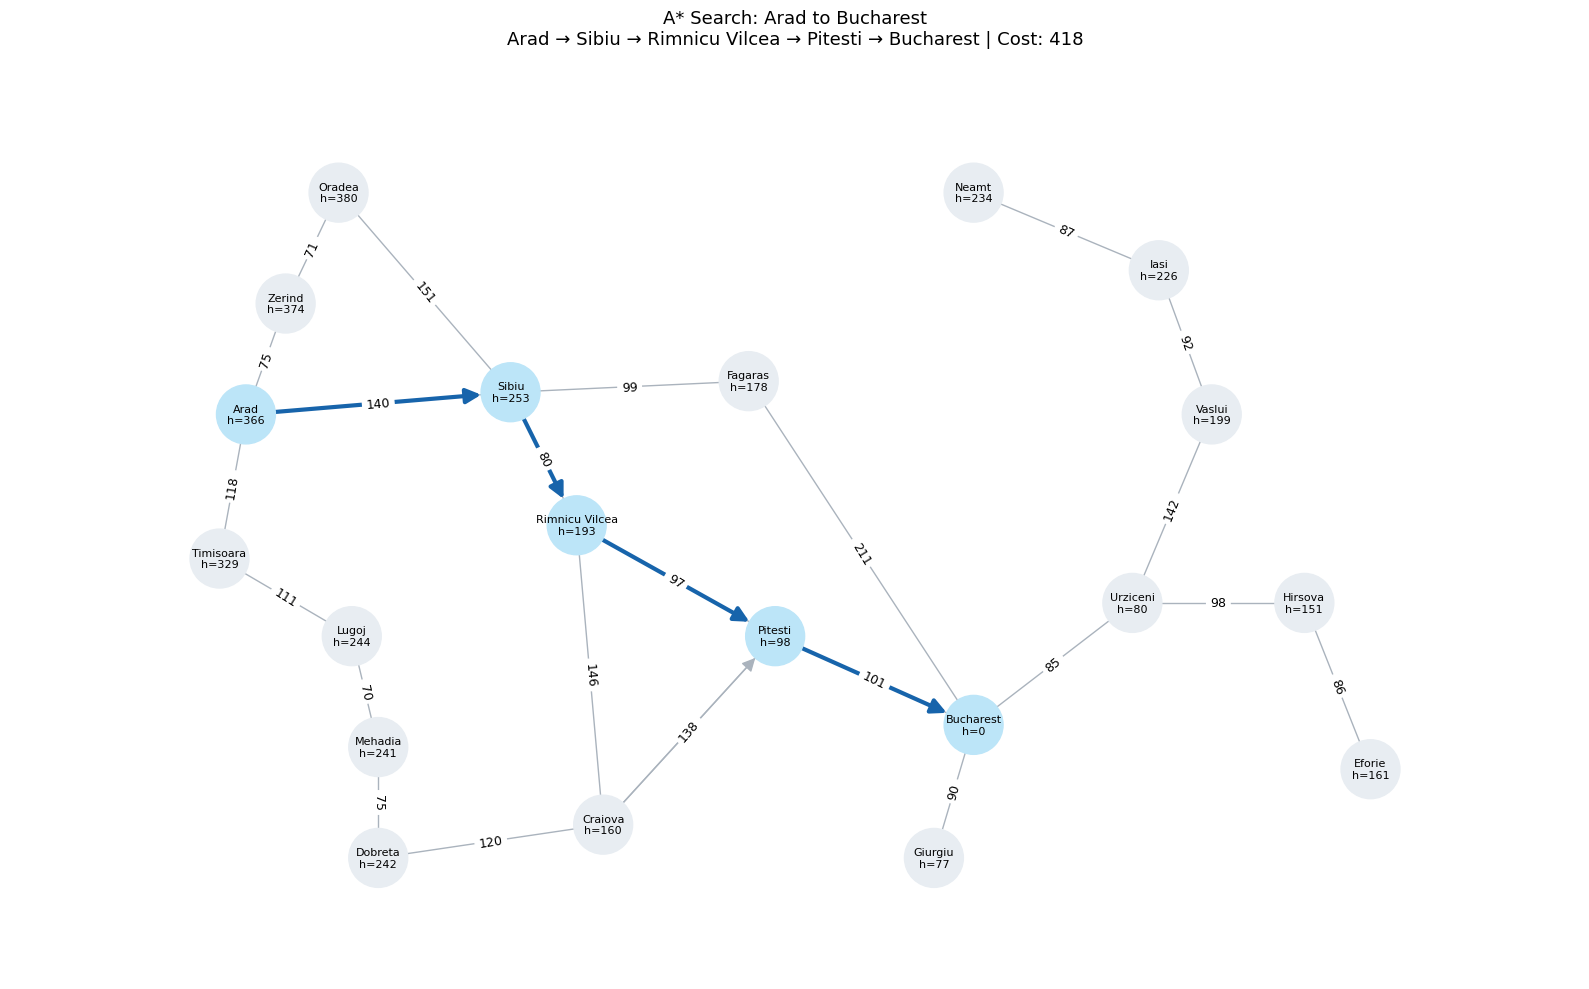

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Run after your existing code.
path = a_star(arad, bucharest)
G, pending, seen = nx.DiGraph(), [arad], set()
while pending:
    node = pending.pop()
    if node in seen: continue
    seen.add(node)
    G.add_node(node.name, h=node.heuristic)
    for neighbor, cost in node.adjacency_list:
        G.add_edge(node.name, neighbor.name, weight=cost)
        pending.append(neighbor)

# Approximate map layout.
pos = {
    'Arad': (0, 4), 'Zerind': (0.3, 5), 'Oradea': (0.7, 6),
    'Sibiu': (2, 4.2), 'Fagaras': (3.8, 4.3), 'Rimnicu Vilcea': (2.5, 3),
    'Timisoara': (-0.2, 2.7), 'Lugoj': (0.8, 2), 'Mehadia': (1, 1),
    'Dobreta': (1, 0), 'Craiova': (2.7, 0.3), 'Pitesti': (4, 2),
    'Bucharest': (5.5, 1.2), 'Giurgiu': (5.2, 0),
    'Urziceni': (6.7, 2.3), 'Hirsova': (8, 2.3), 'Eforie': (8.5, 0.8),
    'Vaslui': (7.3, 4), 'Iasi': (6.9, 5.3), 'Neamt': (5.5, 6)
}

fig, ax = plt.subplots(figsize=(16, 10))

# Draw reciprocal roads once; retain arrows for one-way connections.
roads = G.to_undirected()
nx.draw_networkx_edges(roads, pos, ax=ax, edge_color='#aab3bd')
one_way = [(u, v) for u, v in G.edges if not G.has_edge(v, u)]
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=one_way,
                       edge_color='#aab3bd', arrowsize=20, node_size=1800)

nx.draw_networkx_nodes(
    G, pos, ax=ax, node_size=1800,
    node_color=['#bce5f8' if n in (path or []) else '#e8edf2' for n in G]
)
if path:
    nx.draw_networkx_edges(
        G, pos, ax=ax, edgelist=list(zip(path, path[1:])),
        edge_color='#1764ab', width=3, arrowsize=22, node_size=1800
    )
nx.draw_networkx_labels(
    G, pos, ax=ax, font_size=8,
    labels={n: f"{n}\nh={G.nodes[n]['h']}" for n in G}
)
nx.draw_networkx_edge_labels(
    roads, pos, ax=ax, edge_labels=nx.get_edge_attributes(roads, 'weight'),
    font_size=9
)

result = f"{' → '.join(path)} | Cost: {bucharest.g:g}" if path else "No path found"
print(result)
ax.set_title(f"A* Search: Arad to Bucharest\n{result}", fontsize=13, pad=20)
ax.axis('off')
ax.margins(0.12)
plt.tight_layout()
plt.show()

| Method | Selection rule | Retains alternative branches? | Minimum-cost guarantee |
|---|---|---|---|
| Slide 19 local greedy walk | Smallest neighbour $h$ | No | No |
| Standard greedy best-first search | Smallest frontier $h$ | Yes | No |
| A* in this notebook | Smallest frontier $g+h$ | Yes | With admissible $h$, $h(G)=0$, nonnegative costs, and reopening on a finite graph |
| Uniform-cost search | Smallest frontier $g$ | Yes | With nonnegative costs on a finite graph |

Setting all heuristic values to zero makes A* use the same priority rule as uniform-cost search. Changing the goal also requires a heuristic appropriate to the new goal; the Romania values above estimate distance to Bucharest only.